<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_09_4_stable_diff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 9: Foundations of Generative AI**

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 9 Material

* Part 9.1: Transformer Architecture [[Video]]() [[Notebook]](t81_558_class_09_1_transformers.ipynb)
* Part 9.2: Pretrained Models and the Hugging Face Ecosystem [[Video]]() [[Notebook]](t81_558_class_09_2_hugging.ipynb)
* Part 9.3: Embeddings and Vector Representations [[Video]]() [[Notebook]](t81_558_class_09_3_embedding.ipynb)
* **Part 9.4: Diffusion Models and Image Generation** [[Video]]() [[Notebook]](t81_558_class_09_4_stable_diff.ipynb)
* Part 9.5: Accessing API-Based LLMs [[Video]]() [[Notebook]](t81_558_class_09_5_chat_gpt.ipynb)


# Google CoLab Instructions

The following code detects whether the notebook is running in Google CoLab.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

Note: using Google CoLab


# Part 9.4: Diffusion Models and Image Generation

We will now see how to use Stable Diffusion to create various images from textual prompts. There will be four settings that we will deal with as we generate these images.

* **model**: We will use the trained/finetuned model. Different models are optimized for different types of images.
* **prompt**: Text that you provide to describe what sort of image you would like created.
* **negative prompt**: Text that you describe elements that should not be present in your image.
* **seed**: The same image for the prompt/negative prompt will always be produced for the same seed. To get a different image for the same prompts, change the seed.

We will begin by installing Stable Diffusion into Google CoLab.

In [2]:
!pip install --upgrade diffusers transformers accelerate scipy ftfy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 37.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
  Attempting uninstall: transformers

## Basic Models

To make use of Stable Diffusion we will use the HuggingFace `StableDiffusionPipeline`. When setting up the pipeline we specify the `"CompVis/stable-diffusion-v1-4"` model, which is a basic model created to be used with Stable Diffusion. The following code sets up this model and downloads it from HuggingFace.

In [3]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

We will begin by creating a simple picture of an astronaut playing golf on the moon. We first use the seed of 100; you could also set `seed = -1` to request a random seed. We specify both the prompt and negative prompt.

This pipeline contains code to ensure that no images generated are "not safe for work" (NSFW). This setting tries to protect you from unsafe images. If such an image is generated, you will see the following message:

```
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
```

You may wish to disable this feature. To do this, uncomment the `pipe.safety_checker` line. Be careful, if you do disable this, as unsafe images may be generated containing NSFW themes, which might contain violence, nudity, or sexual themes.

The following code generates the astronaut image.

  0%|          | 0/50 [00:00<?, ?it/s]

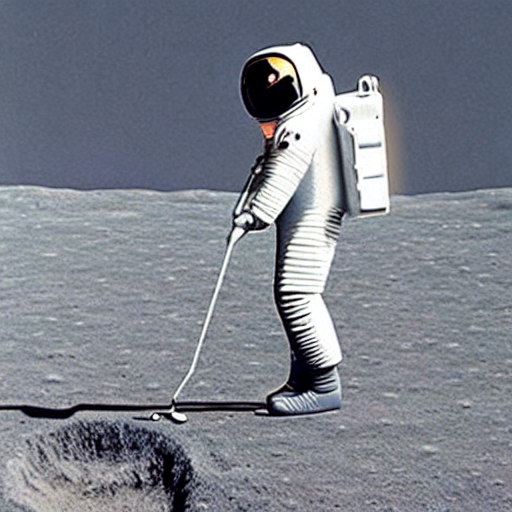

In [4]:
import random

# Random number seed, -1 for random seed
seed = 100  # -1
seed = random.randint(0, 2**32 - 1) if seed == -1 else seed
generator = torch.Generator(device='cuda').manual_seed(int(seed))

# Prompts to generate
prompt = "astronaut playing golf on the moon"

neg_prompt = "signature, watermark"

# pipe.safety_checker = lambda images, clip_input: (images, [False] * len(images))
pipe(prompt, negative_prompt=neg_prompt, width=512, height=512,
     generator=generator).images[0]


## Realistic Models

You might like to try adjusting the code in the previous section to create other images. If you are trying to create images of people, you will be better served with a model like Realistic Vision, which will be demonstrated in this section. The following code loads Realistic Vision.

In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V2.0",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V2.0/snapshots/aaa388343c7f35f6416eea9d29574a4d1ad59817/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V2.0/snapshots/aaa388343c7f35f6416eea9d29574a4d1ad59817/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V2.0/snapshots/aaa388343c7f35f6416eea9d29574a4d1ad59817/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V2.0/snapshots/aaa388343c7f35f6416eea9d29574a4d1ad59817/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


We now generate an image with a much more complex prompt. The positive and negative prompts describe how to generate an image of a young woman. Stable Diffusion prompts are usually comma-separated lists of attributes to draw. You will notice that some are enclosed in parentheses; in some prompt-weighting systems this designates that the attribute is more important, with a number after a colon specifying how important.

Note that the standard `StableDiffusionPipeline` does not interpret the `(token:weight)` syntax — it treats those characters as literal text. To get true prompt weighting, install the [`compel`](https://github.com/damian0815/compel) library and pass `prompt_embeds` to the pipeline. The prompts below will still produce a reasonable image; the weighting just won't be applied.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (141 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['face 1 : 0 . 5 ), ( face 2 : 1 . 2 ), ( face 3 : 0 . 8 5 ), perfect eyes , no makeup . ( skin spores : 1 . 0 5 ), ( skin spores : 1 . 0 5 ), ultra detailed face , ultra detailed skin , film grain , ray tracing , studio lighting']


  0%|          | 0/50 [00:00<?, ?it/s]

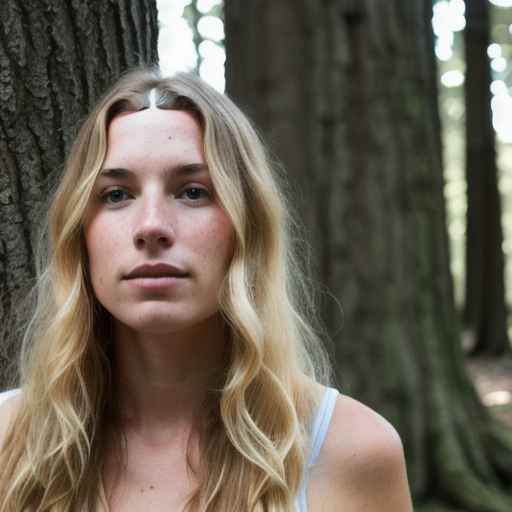

In [6]:
# Random number seed, -1 for random seed
seed = 102  # -1
seed = random.randint(0, 2**32 - 1) if seed == -1 else seed
generator = torch.Generator(device='cuda').manual_seed(int(seed))

# Prompts to generate
prompt = """
(woman age 26 standing by tree), (long blonde hair:1.2), ray traced shadows,
RAW, 8k, (eczema:0.7), (sub-surface scattering:1.55), (sweat:1.22), (freckles:0.55),
highly detailed skin, (Acne:0.7), (FACE1:0.5), (FACE2:1.2), (FACE3:0.85),
perfect eyes, no makeup. (skin spores:1.05), (skin spores:1.05),
ultra detailed face, ultra detailed skin, film grain, ray tracing, studio lighting"""

neg_prompt = """
signature, watermark, airbrush, photoshop, plastic doll,
(ugly eyes, deformed iris, deformed pupils, fused lips and teeth:1.2),
(un-detailed skin, semi-realistic, cgi, 3d, render, sketch, cartoon,
drawing, anime:1.2), text, close up, cropped, out of frame, worst quality,
low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers,
mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry,
dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured,
gross proportions, malformed limbs, missing arms, missing legs, extra arms,
extra legs, fused fingers, too many fingers, long neck, head wear, masculine,
obese, fat, out of frame"""

# pipe.safety_checker = lambda images, clip_input: (images, [False] * len(images))
pipe(prompt, negative_prompt=neg_prompt, width=512, height=512,
     generator=generator).images[0]


## Anime Models

If you would like to generate cartoon or Anime style images, the waifu-diffusion model will work nicely. The code below loads this model and generates an Anime character.

In [7]:
pipe = StableDiffusionPipeline.from_pretrained(
    "hakurei/waifu-diffusion",
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['_ blossoms']


  0%|          | 0/50 [00:00<?, ?it/s]

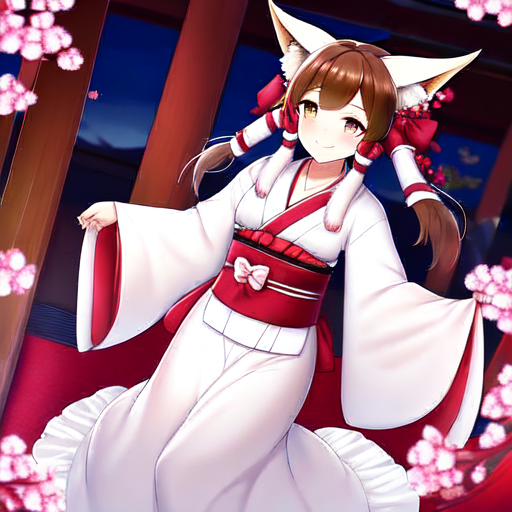

In [8]:
prompt = """
best_quality (1girl:1.3) bow bride brown_hair closed_mouth frilled_bow
frilled_hair_tubes frills (full_body:1.3) fox_ear hair_bow hair_tubes
happy hood japanese_clothes kimono long_sleeves red_bow smile solo tabi
uchikake white_kimono wide_sleeves cherry_blossoms"""
neg_prompt = """
lowres, bad_anatomy, error_body, error_hair, error_arm, error_hands, bad_hands,
error_fingers, bad_fingers, missing_fingers, error_legs, bad_legs, multiple_legs,
missing_legs, error_lighting, error_shadow, error_reflection, text, error,
extra_digit, fewer_digits, cropped, worst_quality, low_quality, normal_quality,
jpeg_artifacts, signature, watermark, username, blurry"""

# Random number seed, -1 for random seed
seed = 105  # -1
seed = random.randint(0, 2**32 - 1) if seed == -1 else seed
generator = torch.Generator(device='cuda').manual_seed(int(seed))

# Generate the image
pipe(prompt, negative_prompt=neg_prompt, width=512, height=512,
     generator=generator).images[0]
